### Assignment 4
**Recurrent Neural Network (RNN)**: Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [133]:
# load the dataset
df = pd.read_csv('Google_Stock.csv', thousands=',')


In [134]:
print("Shape of data: ",df.shape)

Shape of data:  (1258, 6)


In [135]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800


In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   str    
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   float64
 5   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 59.1 KB


In [137]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [138]:
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

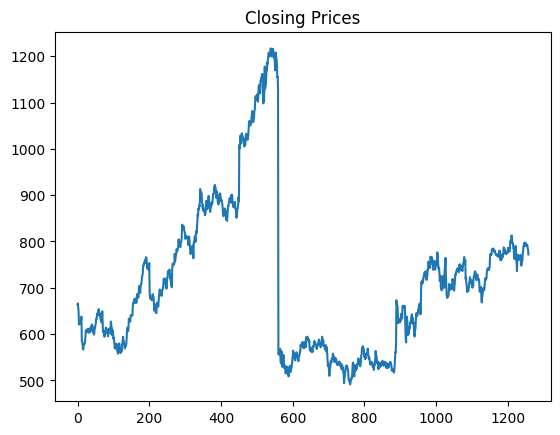

In [139]:
# visualize
close = df[['Close']].values

plt.plot(close)
plt.title("Closing Prices")
fig.set_ylabel("Stock Price")
fig.set_xlabel("Date")
plt.show()

In [140]:
# select only features, not date
data = df.drop('Date', axis=1)

In [141]:
# Scale data
scaled = MinMaxScaler().fit_transform(close)

# Train-test split
split = int(len(scaled) * 0.8)
train, test = scaled[:split], scaled[split:]

In [142]:
# Create sequences
def create_dataset(data, step=4):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

x_train, y_train = create_dataset(train)
x_test, y_test = create_dataset(test)

In [143]:
# Build model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/home/naveed-malik/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [144]:
# train the model
history = model.fit(x_train, y_train, epochs=50, verbose =1,validation_split = 0.2)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0512 - val_loss: 0.0036
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - val_loss: 9.3235e-04
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 8.0259e-04
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - val_loss: 8.0329e-04
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - val_loss: 8.4177e-04
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 7.1406e-04
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 7.3682e-04
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 7.5705e-04
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 6.7969e-04
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 7.4407e-04
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 7.9792e-04
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━

In [145]:
y_pred = model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [146]:
# Predict and inverse scale
scaler = MinMaxScaler().fit(close)
y_pred = scaler.inverse_transform(model.predict(x_test))
y_test = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


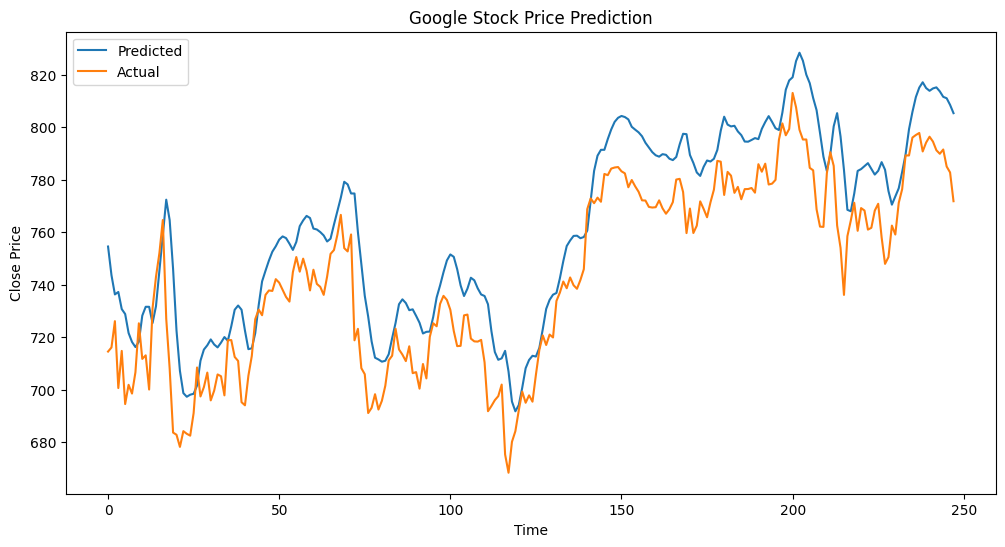

In [147]:
plt.figure(figsize=(12, 6))

# Plot results
plt.plot(y_pred, label="Predicted")
plt.plot(y_test, label="Actual")
plt.legend()
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.show()

In [148]:
# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
r2 = r2_score(actual_values, predicted_values)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  12.070325353063888
MAE:  9.311255896783647
R2 Score:  0.8786259319734174


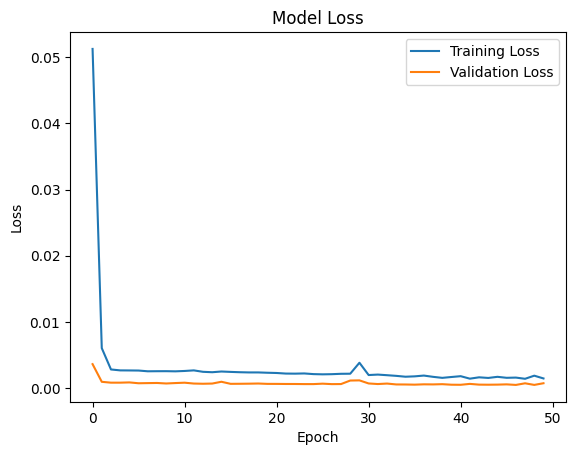

In [149]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()